# Chi-Square Test — Association Between Device Type and Customer Satisfaction
**Company:** Mizzare Corporation  
**Objective:** Determine if there is a significant association between the type of smart home device purchased (Smart Thermostat vs Smart Light) and the customer satisfaction level using the Chi-Square Test for Independence.

---
## 0. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, chi2
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded.')

Libraries loaded.


---
## Data

In [2]:
satisfaction_levels = ['Very Satisfied', 'Satisfied', 'Neutral', 'Unsatisfied', 'Very Unsatisfied']
observed_data = np.array([
    [50, 70],
    [80, 100],
    [60, 90],
    [30, 50],
    [20, 50]
], dtype=float)

obs_df = pd.DataFrame(observed_data, index=satisfaction_levels,
                      columns=['Smart Thermostat', 'Smart Light'])
display_df = obs_df.copy()
display_df['Total'] = display_df.sum(axis=1)
display_df.loc['Total'] = display_df.sum()
print('Contingency Table (Observed Frequencies):')
display_df

Contingency Table (Observed Frequencies):


,Smart Thermostat,Smart Light,Total
Very Satisfied,50.0,70.0,120.0
Satisfied,80.0,100.0,180.0
Neutral,60.0,90.0,150.0
Unsatisfied,30.0,50.0,80.0
Very Unsatisfied,20.0,50.0,70.0
Total,240.0,360.0,600.0


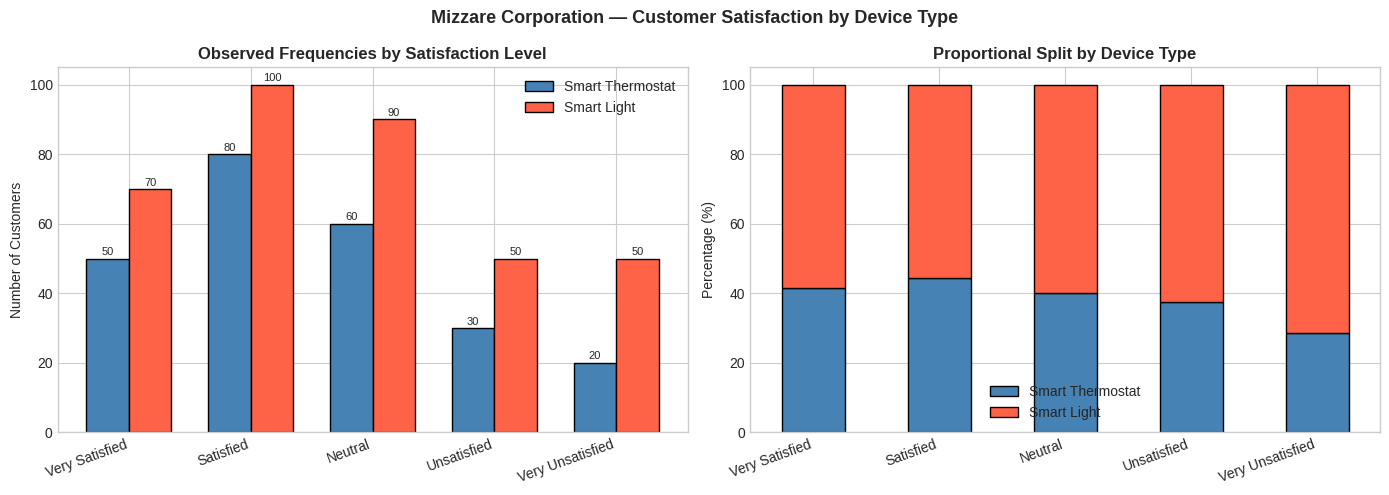

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(satisfaction_levels))
width = 0.35
bars1 = axes[0].bar(x - width/2, obs_df['Smart Thermostat'], width,
                    label='Smart Thermostat', color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, obs_df['Smart Light'], width,
                    label='Smart Light', color='tomato', edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(satisfaction_levels, rotation=20, ha='right')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Observed Frequencies by Satisfaction Level', fontweight='bold')
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, int(bar.get_height()), ha='center', fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, int(bar.get_height()), ha='center', fontsize=8)

obs_pct = obs_df.div(obs_df.sum(axis=1), axis=0) * 100
obs_pct.plot(kind='bar', stacked=True, ax=axes[1],
             color=['steelblue', 'tomato'], edgecolor='black')
axes[1].set_xticklabels(satisfaction_levels, rotation=20, ha='right')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Proportional Split by Device Type', fontweight='bold')
axes[1].legend()

plt.suptitle('Mizzare Corporation — Customer Satisfaction by Device Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 1 — State the Hypotheses

In [4]:
print('=' * 65)
print('HYPOTHESES')
print('=' * 65)
print()
print('H₀ (Null Hypothesis):')
print('   There is NO significant association between the type of')
print('   smart home device purchased and customer satisfaction.')
print('   → Device type and satisfaction are INDEPENDENT.')
print()
print('H₁ (Alternative Hypothesis):')
print('   There IS a significant association between the type of')
print('   smart home device purchased and customer satisfaction.')
print('   → Device type and satisfaction are DEPENDENT.')
print()
print('Significance Level  α = 0.05')

HYPOTHESES

H₀ (Null Hypothesis):
   There is NO significant association between the type of
   smart home device purchased and customer satisfaction.
   → Device type and satisfaction are INDEPENDENT.

H₁ (Alternative Hypothesis):
   There IS a significant association between the type of
   smart home device purchased and customer satisfaction.
   → Device type and satisfaction are DEPENDENT.

Significance Level  α = 0.05


---
## Task 2 — Compute the Chi-Square Statistic

In [5]:
# Expected frequencies: E_ij = (row_total_i * col_total_j) / grand_total
row_totals  = observed_data.sum(axis=1)
col_totals  = observed_data.sum(axis=0)
grand_total = observed_data.sum()
E = np.outer(row_totals, col_totals) / grand_total

exp_df = pd.DataFrame(E, index=satisfaction_levels,
                      columns=['Smart Thermostat (E)', 'Smart Light (E)'])
print('Expected Frequencies E_ij = (Row Total × Col Total) / Grand Total:')
print(exp_df.round(4))

Expected Frequencies E_ij = (Row Total × Col Total) / Grand Total:
                  Smart Thermostat (E)  Smart Light (E)
Very Satisfied                    48.0             72.0
Satisfied                         72.0            108.0
Neutral                           60.0             90.0
Unsatisfied                       32.0             48.0
Very Unsatisfied                  28.0             42.0


In [6]:
# Chi-Square: χ² = Σ [(O - E)² / E]
components = (observed_data - E) ** 2 / E

comp_df = pd.DataFrame(components, index=satisfaction_levels,
                       columns=['Smart Thermostat', 'Smart Light'])
print('Chi-Square Components  (O − E)² / E:')
print(comp_df.round(6))

Chi-Square Components  (O − E)² / E:
                  Smart Thermostat  Smart Light
Very Satisfied            0.083333     0.055556
Satisfied                 0.888889     0.592593
Neutral                   0.000000     0.000000
Unsatisfied               0.125000     0.083333
Very Unsatisfied          2.285714     1.523810


In [7]:
# Detailed step-by-step table
devices = ['Smart Thermostat', 'Smart Light']
print(f'{"Satisfaction":<22} {"Device":<20} {"O":>5} {"E":>8} {"O-E":>7} {"(O-E)²":>9} {"(O-E)²/E":>10}')
print('-' * 83)
chi2_manual = 0
for i, sat in enumerate(satisfaction_levels):
    for j, dev in enumerate(devices):
        o = observed_data[i, j]
        e = E[i, j]
        diff = o - e
        sq   = diff ** 2
        comp = sq / e
        chi2_manual += comp
        print(f'{sat:<22} {dev:<20} {o:>5.0f} {e:>8.2f} {diff:>7.2f} {sq:>9.4f} {comp:>10.6f}')
print('-' * 83)
print(f'{"TOTAL":<64} {chi2_manual:>10.6f}')
print(f'\nχ² Statistic (manual) = {chi2_manual:.4f}')

Satisfaction           Device                   O        E     O-E    (O-E)²   (O-E)²/E
-----------------------------------------------------------------------------------
Very Satisfied         Smart Thermostat        50    48.00    2.00    4.0000   0.083333
Very Satisfied         Smart Light             70    72.00   -2.00    4.0000   0.055556
Satisfied              Smart Thermostat        80    72.00    8.00   64.0000   0.888889
Satisfied              Smart Light            100   108.00   -8.00   64.0000   0.592593
Neutral                Smart Thermostat        60    60.00    0.00    0.0000   0.000000
Neutral                Smart Light             90    90.00    0.00    0.0000   0.000000
Unsatisfied            Smart Thermostat        30    32.00   -2.00    4.0000   0.125000
Unsatisfied            Smart Light             50    48.00    2.00    4.0000   0.083333
Very Unsatisfied       Smart Thermostat        20    28.00   -8.00   64.0000   2.285714
Very Unsatisfied       Smart Light  

In [8]:
# Verify with scipy
chi2_stat, p_value, dof, expected_scipy = chi2_contingency(observed_data, correction=False)
print(f'χ² Statistic (scipy)   = {chi2_stat:.4f}')
print(f'P-value                = {p_value:.4f}')
print(f'Degrees of Freedom     = {dof}')
print(f'Manual matches scipy   : {np.isclose(chi2_manual, chi2_stat)}')

χ² Statistic (scipy)   = 5.6382
P-value                = 0.2278
Degrees of Freedom     = 4
Manual matches scipy   : True


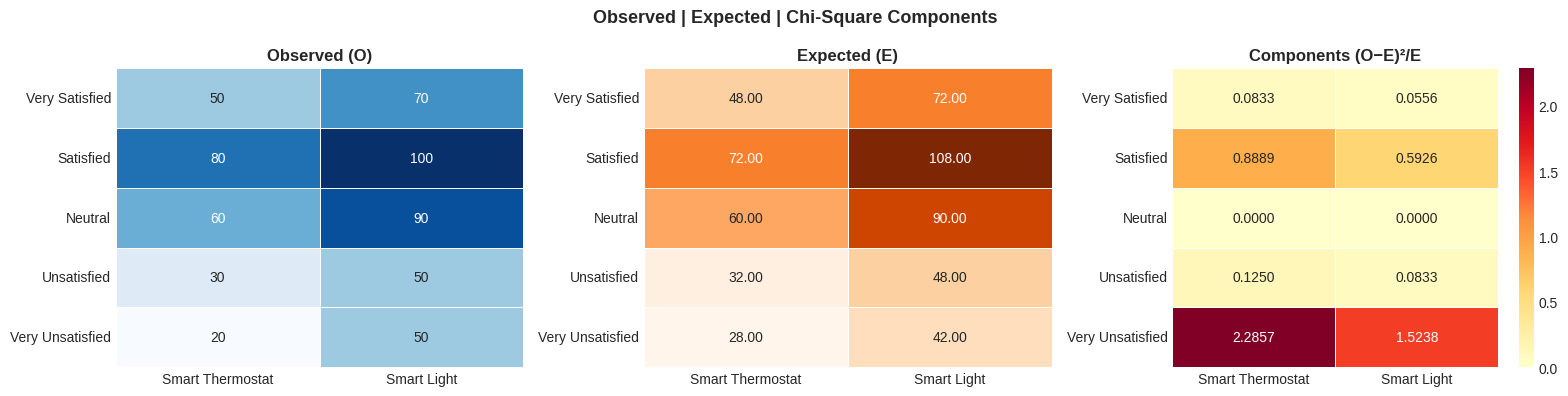

In [9]:
# Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.heatmap(obs_df, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[0], cbar=False)
axes[0].set_title('Observed (O)', fontweight='bold')

sns.heatmap(exp_df.rename(columns=lambda c: c.replace(' (E)', '')),
            annot=True, fmt='.2f', cmap='Oranges',
            linewidths=0.5, ax=axes[1], cbar=False)
axes[1].set_title('Expected (E)', fontweight='bold')

sns.heatmap(comp_df, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[2], cbar=True)
axes[2].set_title('Components (O−E)²/E', fontweight='bold')

plt.suptitle('Observed | Expected | Chi-Square Components', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Task 3 — Determine the Critical Value

In [10]:
alpha   = 0.05
n_rows  = observed_data.shape[0]
n_cols  = observed_data.shape[1]
dof_val = (n_rows - 1) * (n_cols - 1)
crit_val = chi2.ppf(1 - alpha, df=dof_val)

print(f'Significance Level (α)        = {alpha}')
print(f'Rows (satisfaction levels)    = {n_rows}')
print(f'Columns (device types)        = {n_cols}')
print(f'Degrees of Freedom            = ({n_rows}-1) × ({n_cols}-1) = {dof_val}')
print(f'Critical Value χ²(α=0.05,df={dof_val}) = {crit_val:.4f}')
print(f'\n→ Reject H₀ if χ² > {crit_val:.4f}')

Significance Level (α)        = 0.05
Rows (satisfaction levels)    = 5
Columns (device types)        = 2
Degrees of Freedom            = (5-1) × (2-1) = 4
Critical Value χ²(α=0.05,df=4) = 9.4877

→ Reject H₀ if χ² > 9.4877


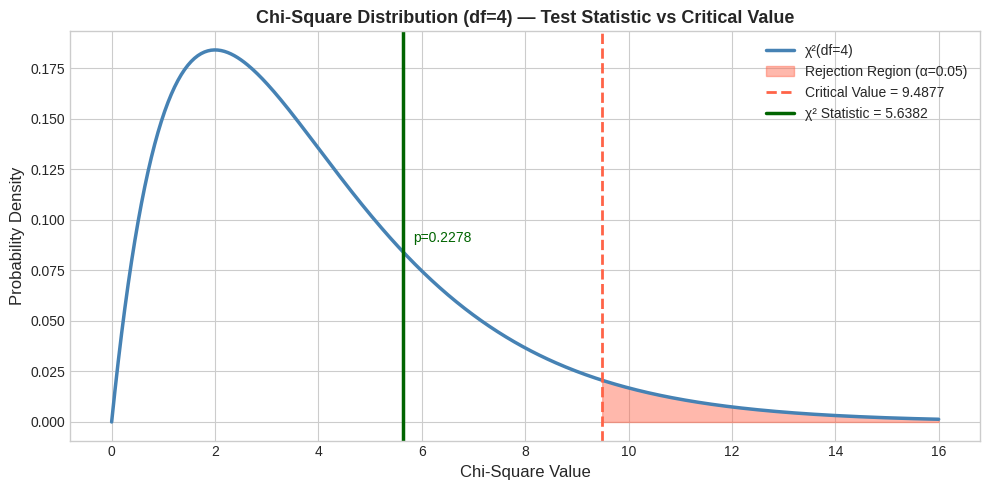

In [11]:
# Chi-Square distribution curve with critical region
x_vals = np.linspace(0, 16, 500)
y_vals = chi2.pdf(x_vals, df=dof_val)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, y_vals, color='steelblue', linewidth=2.5, label=f'χ²(df={dof_val})')

x_rej = x_vals[x_vals >= crit_val]
plt.fill_between(x_rej, chi2.pdf(x_rej, df=dof_val),
                 alpha=0.45, color='tomato', label=f'Rejection Region (α={alpha})')

plt.axvline(crit_val,   color='tomato',    linestyle='--', linewidth=2,
            label=f'Critical Value = {crit_val:.4f}')
plt.axvline(chi2_stat,  color='darkgreen', linestyle='-',  linewidth=2.5,
            label=f'χ² Statistic = {chi2_stat:.4f}')

# Annotate p-value
plt.text(chi2_stat + 0.2, chi2.pdf(chi2_stat, df=dof_val) + 0.005,
         f'p={p_value:.4f}', color='darkgreen', fontsize=10)

plt.xlabel('Chi-Square Value', fontsize=12)
plt.ylabel('Probability Density', fontsize=12)
plt.title(f'Chi-Square Distribution (df={dof_val}) — Test Statistic vs Critical Value',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

---
## Task 4 — Make a Decision

In [12]:
reject = chi2_stat > crit_val

print('=' * 65)
print('DECISION')
print('=' * 65)
print(f'\n  χ² Statistic          = {chi2_stat:.4f}')
print(f'  Critical Value        = {crit_val:.4f}')
print(f'  P-value               = {p_value:.4f}')
print(f'  Alpha (α)             = {alpha}')
print()
print(f'  χ² ({chi2_stat:.4f}) {">">3 if reject else "<=":>2} χ²_crit ({crit_val:.4f})')
print(f'  p-value ({p_value:.4f}) {"<" if reject else ">="} α ({alpha})')
print()
if reject:
    print('  Decision : REJECT H₀')
    print()
    print('  Conclusion:')
    print('  There IS a statistically significant association between')
    print('  device type and customer satisfaction level.')
else:
    print('  Decision : FAIL TO REJECT H₀')
    print()
    print('  Conclusion:')
    print('  There is NO statistically significant association between')
    print('  device type and customer satisfaction level.')
    print('  The data does not provide sufficient evidence to conclude')
    print('  that device type influences customer satisfaction.')
print('=' * 65)

DECISION

  χ² Statistic          = 5.6382
  Critical Value        = 9.4877
  P-value               = 0.2278
  Alpha (α)             = 0.05

  χ² (5.6382) <= χ²_crit (9.4877)
  p-value (0.2278) >= α (0.05)

  Decision : FAIL TO REJECT H₀

  Conclusion:
  There is NO statistically significant association between
  device type and customer satisfaction level.
  The data does not provide sufficient evidence to conclude
  that device type influences customer satisfaction.


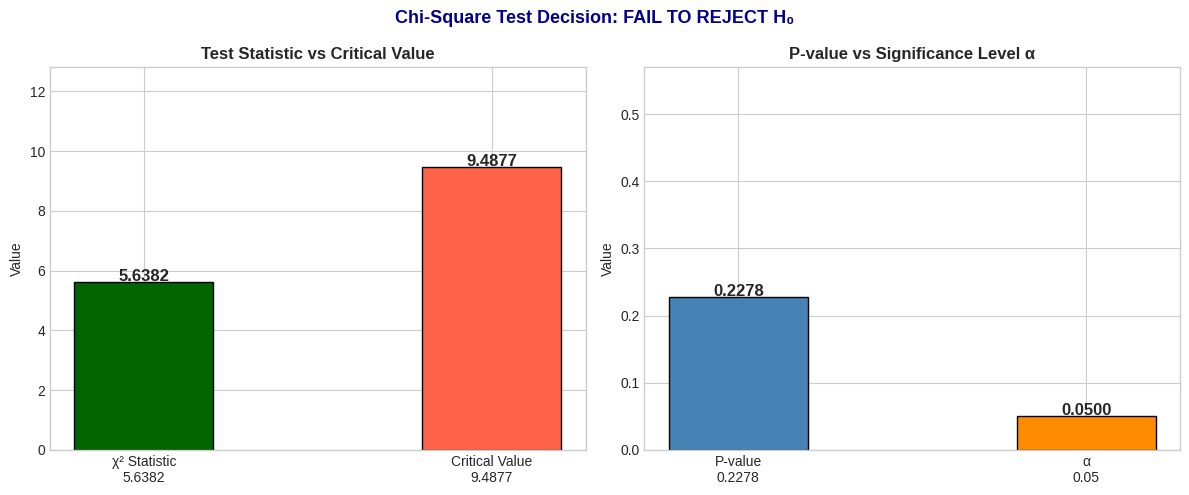

In [13]:
# Summary decision chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels1 = [f'χ² Statistic\n{chi2_stat:.4f}', f'Critical Value\n{crit_val:.4f}']
vals1   = [chi2_stat, crit_val]
colors1 = ['darkgreen', 'tomato']
bars1   = axes[0].bar(labels1, vals1, color=colors1, edgecolor='black', width=0.4)
for bar, v in zip(bars1, vals1):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Test Statistic vs Critical Value', fontweight='bold')
axes[0].set_ylim(0, max(vals1)*1.35)
axes[0].set_ylabel('Value')

labels2 = [f'P-value\n{p_value:.4f}', f'α\n{alpha}']
vals2   = [p_value, alpha]
colors2 = ['steelblue', 'darkorange']
bars2   = axes[1].bar(labels2, vals2, color=colors2, edgecolor='black', width=0.4)
for bar, v in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{v:.4f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('P-value vs Significance Level α', fontweight='bold')
axes[1].set_ylim(0, max(vals2)*2.5)
axes[1].set_ylabel('Value')

decision_text = 'REJECT H₀' if reject else 'FAIL TO REJECT H₀'
plt.suptitle(f'Chi-Square Test Decision: {decision_text}',
             fontsize=13, fontweight='bold',
             color='darkred' if reject else 'darkblue')
plt.tight_layout()
plt.show()

---
## Summary Report

| Step | Detail | Value |
|---|---|---|
| H₀ | No association between device type and satisfaction | — |
| H₁ | Significant association exists | — |
| Significance Level α | — | 0.05 |
| Degrees of Freedom | (5−1) × (2−1) | 4 |
| Chi-Square Statistic χ² | Σ [(O−E)²/E] | 5.6382 |
| Critical Value | χ²(df=4, α=0.05) | 9.4877 |
| P-value | — | 0.2278 |
| Decision | χ² < χ²_crit and p > α | **Fail to Reject H₀** |

**Conclusion:**  
At the 5% significance level, there is **no statistically significant association** between the type of smart home device purchased (Smart Thermostat vs Smart Light) and the customer satisfaction level. The observed differences between the two product groups are consistent with chance variation. Mizzare Corporation can conclude that both products yield comparable satisfaction profiles in the sampled customer base.